In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import cvxpy as cp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



In [ ]:
class DoublePendulumDynamics:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        # state: [θ1, θ2, ω1, ω2], u: [τ1, τ2]
        θ1, θ2, ω1, ω2 = state
        m1, m2, l1, l2, g = self.m1, self.m2, self.l1, self.l2, self.g
        Δ = θ2 - θ1
        M11 = (m1 + m2) * l1**2
        M12 = m2 * l1 * l2 * np.cos(Δ)
        M21 = M12
        M22 = m2 * l2**2
        C1 = -m2 * l1 * l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = m2 * l1 * l2 * ω1**2 * np.sin(Δ)
        G1 = -(m1 + m2) * g * l1 * np.sin(θ1)
        G2 = -m2 * g * l2 * np.sin(θ2)
        M = np.array([[M11, M12],[M21, M22]])
        C = np.array([C1, C2])
        G = np.array([G1, G2])
        dd = np.linalg.inv(M) @ (u - C - G)
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    
    def forward_kinematics(self, state):
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])

def plot_pendulum(ax, θ1, θ2, l1=1.0, l2=1.0, **kwargs):
    x1, y1 = l1*np.sin(θ1), -l1*np.cos(θ1)
    x2, y2 = x1 + l2*np.sin(θ2), y1 - l2*np.cos(θ2)
    ax.plot([0, x1], [0, y1], lw=2, **kwargs)
    ax.plot([x1, x2], [y1, y2], lw=2, **kwargs)
    ax.scatter([0, x1, x2], [0, y1, y2], s=50, **kwargs)




In [ ]:

class MPCController:
    def __init__(self, dyn, N=20, dt=0.1, Q=np.diag([10,10,1,1]), R=np.diag([0.1,0.1])):
        self.dyn = dyn
        self.N, self.dt = N, dt
        self.Q, self.R = Q, R
        self.nx, self.nu = 4, 2

    def solve(self, x0, x_target):
        X = cp.Variable((self.nx, self.N+1))
        U = cp.Variable((self.nu, self.N))
        cost = 0
        constraints = []
        constraints += [X[:,0] == x0]
        for k in range(self.N):
            xk = X[:,k]
            uk = U[:,k]
            x_next = xk + self.dt * self.dyn.f(xk.value if xk.value is not None else x0, uk) if False else xk + self.dt * self.dyn.f(xk, uk)
            constraints += [X[:,k+1] == xk + self.dt * self.dyn.f(xk, uk)]
            cost += cp.quad_form(X[:,k]-x_target, self.Q) + cp.quad_form(uk, self.R)
        cost += cp.quad_form(X[:,self.N]-x_target, self.Q)
        prob = cp.Problem(cp.Minimize(cost), constraints)
        prob.solve(solver=cp.OSQP)
        return U.value[:,0]


start status: θ1=-1.75, θ2=2.33, ω1=0.00, ω2=0.00


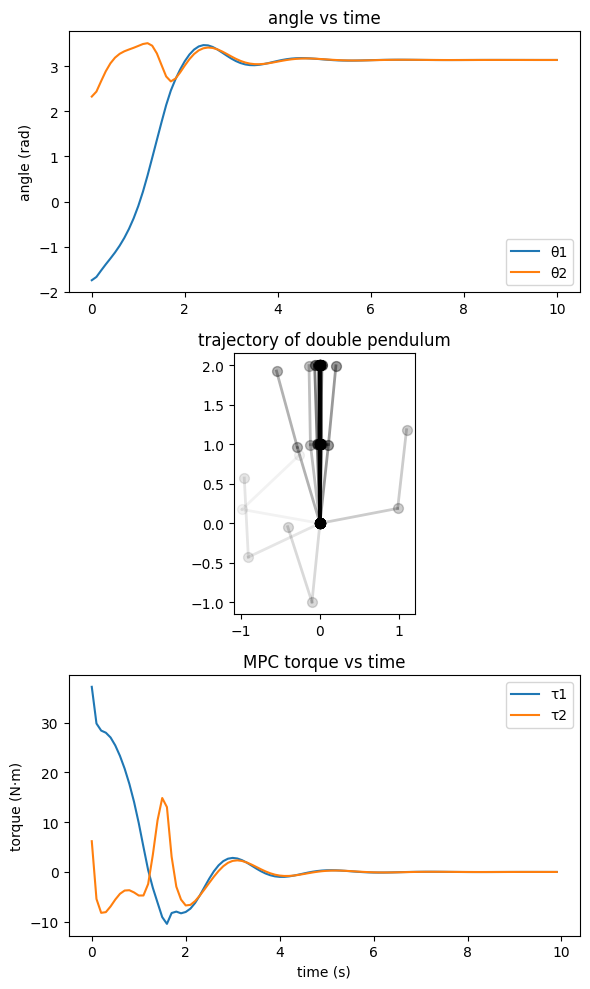

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import cvxpy as cp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class DoublePendulumDynamics:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        θ1, θ2, ω1, ω2 = state
        Δ = θ2 - θ1
        M11 = (self.m1 + self.m2) * self.l1**2
        M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
        M21 = M12
        M22 = self.m2 * self.l2**2
        C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
        G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
        G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
        M = np.array([[M11, M12],[M21, M22]])
        dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)


def plot_pendulum(ax, θ1, θ2, l1=1.0, l2=1.0, **kwargs):
    x1, y1 = l1*np.sin(θ1), -l1*np.cos(θ1)
    x2, y2 = x1 + l2*np.sin(θ2), y1 - l2*np.cos(θ2)
    ax.plot([0, x1], [0, y1], lw=2, **kwargs)
    ax.plot([x1, x2], [y1, y2], lw=2, **kwargs)
    ax.scatter([0, x1, x2], [0, y1, y2], s=50, **kwargs)

class MPCController:
    def __init__(self, dyn, N=20, dt=0.1, Q=None, R=None):
        self.dyn = dyn
        self.N, self.dt = N, dt
        self.nx, self.nu = 4, 2
        self.Q = np.diag([10,10,1,1]) if Q is None else Q
        self.R = np.diag([0.1,0.1]) if R is None else R

    def solve(self, x0, x_target):
        X = cp.Variable((self.nx, self.N+1))
        U = cp.Variable((self.nu, self.N))
        cost = 0
        constraints = [X[:,0] == x0]
        for k in range(self.N):
            xk = X[:,k]
            uk = U[:,k]

            next_est = cp.hstack([xk[2], xk[3], uk[0], uk[1]])
            constraints += [X[:,k+1] == xk + self.dt * next_est]
            cost += cp.quad_form(xk - x_target, self.Q) + cp.quad_form(uk, self.R)
        cost += cp.quad_form(X[:,self.N] - x_target, self.Q)
        prob = cp.Problem(cp.Minimize(cost), constraints)
        prob.solve(solver=cp.OSQP)
        return U.value[:,0]

np.random.seed(5)

x0 = np.concatenate([np.random.uniform(-np.pi, np.pi, 2), np.zeros(2)])

print(f"start status: θ1={x0[0]:.2f}, θ2={x0[1]:.2f}, ω1={x0[2]:.2f}, ω2={x0[3]:.2f}")

x_target = np.array([np.pi, np.pi, 0.0, 0.0])
dyn = DoublePendulumDynamics()
mpc = MPCController(dyn, N=20, dt=0.1)

T = 100
dt = 0.1
times = np.arange(T+1) * dt
states = [x0.copy()]
actions = []
for _ in range(T):
    u = mpc.solve(states[-1], x_target)
    actions.append(u)
    states.append(dyn.rk4_step(states[-1], u, dt))
states = np.array(states)
actions = np.array(actions)  
t_u = times[:-1]           

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(6,10))

ax1.plot(times, states[:,0], label='θ1')
ax1.plot(times, states[:,1], label='θ2')
ax1.set_ylabel('angle (rad)')
ax1.legend()
ax1.set_title('angle vs time')

for i in range(20):
    idx = int(i * (T / 19))
    alpha = (i+1)/20
    plot_pendulum(ax2, states[idx,0], states[idx,1], alpha=alpha, color='black')
ax2.set_title('trajectory of double pendulum') 
ax2.set_aspect('equal')

ax3.plot(t_u, actions[:,0], label='τ1')
ax3.plot(t_u, actions[:,1], label='τ2')
ax3.set_xlabel('time (s)')
ax3.set_ylabel('torque (N·m)')
ax3.legend()
ax3.set_title('MPC torque vs time')

plt.tight_layout()
plt.show()


In [ ]:


np.random.seed(8) 
x0 = np.concatenate([np.random.uniform(-np.pi, np.pi, 2), np.zeros(2)])
print(f"start status: θ1={x0[0]:.2f}, θ2={x0[1]:.2f}, ω1={x0[2]:.2f}, ω2={x0[3]:.2f}")

x_target = np.array([np.pi, np.pi, 0.0, 0.0])
dyn = DoublePendulumDynamics()
mpc = MPCController(dyn, N=20, dt=0.1)

dt = 0.1
## Generate trajectories if you don't have
# num_episodes = 5000
# T = 100
# data = np.zeros((num_episodes, T, 6))  # θ1, θ2, ω1, ω2, τ1, τ2

# for ep in range(num_episodes):
     
#     x = np.concatenate([np.random.uniform(0, 2*np.pi, 2), np.zeros(2)])
#     for t in range(T):
#         u = mpc.solve(x, x_target)
#         data[ep, t, :4] = x.copy()
#         data[ep, t, 4:] = u.copy()
#         x = dyn.rk4_step(x, u, dt)

# np.save('mpc_trajectories.npy', data)
# print("Saved data shape:", data.shape)


start status: θ1=2.35, θ2=2.94, ω1=0.00, ω2=0.00


In [6]:
# %%
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

# fmtorch imports
from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper
from fmtorch.models import UNetModel



In [7]:
# %%
# 1. Load MPC trajectories
data = np.load('mpc_trajectories.npy')
print(f"Loaded data shape: {data.shape}")  # (5000, 100, 6)

# %%
# 2. Define Scaler for normalization
class Scaler:
    def __init__(self, data_min, data_max):
        self.min = data_min
        self.max = data_max
        self.range = self.max - self.min
        # Add small epsilon to avoid division by zero
        self.range = np.where(self.range < 1e-8, 1.0, self.range)
    
    def normalize(self, x):
        return 2 * (x - self.min) / self.range - 1
    
    def denormalize(self, x_norm):
        return (x_norm + 1) / 2 * self.range + self.min

# %%
# 3. Compute min/max for states and controls
states_all = data[:, :, :4].reshape(-1, 4)  # θ1, θ2, ω1, ω2
controls_all = data[:, :, 4:].reshape(-1, 2)  # τ1, τ2

state_min = states_all.min(axis=0)
state_max = states_all.max(axis=0)
control_min = controls_all.min(axis=0)
control_max = controls_all.max(axis=0)

print(f"State range: {state_min} to {state_max}")
print(f"Control range: {control_min} to {control_max}")

state_scaler = Scaler(state_min, state_max)
control_scaler = Scaler(control_min, control_max)

# %%
# 4. Dataset for MPC trajectories
class MPCTrajectoryDataset(Dataset):
    def __init__(self, data, state_scaler, control_scaler):
        self.data = data
        self.state_scaler = state_scaler
        self.control_scaler = control_scaler
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        traj = self.data[idx]  # (100, 6)
        states = traj[:, :4]   # (100, 4)
        controls = traj[:, 4:] # (100, 2)
        
        # Normalize
        states_norm = self.state_scaler.normalize(states)
        controls_norm = self.control_scaler.normalize(controls)
        
        # Combine and transpose for (channels, time) format
        combined = np.concatenate([states_norm.T, controls_norm.T], axis=0)  # (6, 100)
        
        return torch.from_numpy(combined.astype(np.float32))

# %%
# 5. Create DataLoader
batch_size = 64
train_dataset = MPCTrajectoryDataset(data, state_scaler, control_scaler)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"Dataset size: {len(train_dataset)}")
print(f"Batch shape: {next(iter(train_loader)).shape}")  # (batch_size, 6, 100)


Loaded data shape: (5000, 100, 6)
State range: [ 2.56088729e-04  2.56455152e-03 -7.90690687e+00 -6.95487547e+00] to [6.28316822 6.28270394 7.9152857  6.93838446]
Control range: [-27.72539268 -26.14946545] to [27.87833237 26.44831293]
Dataset size: 5000
Batch shape: torch.Size([64, 6, 100])


In [8]:
class SimpleFlowTransformer(nn.Module):
    """Simple transformer for flow matching - fast and stable"""
    def __init__(self, in_channels=6, hidden_dim=128, num_heads=4, num_layers=4, time_dim=100):
        super().__init__()
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
        # Input projection
        self.input_proj = nn.Conv1d(in_channels, hidden_dim, 1)
        
        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(1, hidden_dim, time_dim))
        
        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=0.1,
                activation='gelu',
                batch_first=True,
                norm_first=True
            ) for _ in range(num_layers)
        ])
        
        # Output projection
        self.output_proj = nn.Conv1d(hidden_dim, in_channels, 1)
        
    def forward(self, x, t):
        # Input projection
        h = self.input_proj(x)  # (B, hidden_dim, 100)
        
        # Add positional encoding
        h = h + self.pos_encoding
        
        # Time embedding
        t_embed = self.time_embed(t.unsqueeze(-1))  # (B, hidden_dim)
        
        # Reshape for transformer (B, T, C)
        h = h.transpose(1, 2)  # (B, 100, hidden_dim)
        
        # Add time embedding to each position
        h = h + t_embed.unsqueeze(1)
        
        # Apply transformer blocks
        for block in self.transformer_blocks:
            h = block(h)
        
        # Reshape back and project
        h = h.transpose(1, 2)  # (B, hidden_dim, 100)
        out = self.output_proj(h)  # (B, 6, 100)
        
        return out

class TemporalConvBlock(nn.Module):
    """1D temporal convolution block with residual connection"""
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              stride=stride, padding=padding, dilation=dilation)
        self.norm = nn.GroupNorm(min(8, out_channels), out_channels)
        self.activation = nn.GELU()
        
        # Residual connection
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
    def forward(self, x):
        out = self.activation(self.norm(self.conv(x)))
        return out + self.residual(x)

class EfficientTemporalUNet(nn.Module):
    """Lightweight 1D U-Net for temporal data"""
    def __init__(self, in_channels=6, base_channels=32, time_embed_dim=64):
        super().__init__()
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.GELU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
        
        # Encoder
        self.enc1 = TemporalConvBlock(in_channels, base_channels)
        self.enc2 = TemporalConvBlock(base_channels, base_channels * 2)
        self.enc3 = TemporalConvBlock(base_channels * 2, base_channels * 4)
        
        # Middle
        self.mid = nn.Sequential(
            TemporalConvBlock(base_channels * 4, base_channels * 4),
            TemporalConvBlock(base_channels * 4, base_channels * 4),
        )
        
        # Time conditioning layers
        self.time_layers = nn.ModuleList([
            nn.Linear(time_embed_dim, base_channels),
            nn.Linear(time_embed_dim, base_channels * 2),
            nn.Linear(time_embed_dim, base_channels * 4),
        ])
        
        # Decoder
        self.dec3 = TemporalConvBlock(base_channels * 8, base_channels * 2)
        self.dec2 = TemporalConvBlock(base_channels * 4, base_channels)
        self.dec1 = TemporalConvBlock(base_channels * 2, base_channels)
        
        # Output
        self.out = nn.Conv1d(base_channels, in_channels, 1)
        
        # Pooling with ceil mode to handle odd dimensions
        self.pool = nn.MaxPool1d(2, ceil_mode=True)
        
    def forward(self, x, t):
        # Time embedding
        t_embed = self.time_embed(t.unsqueeze(-1))
        
        # Encoder
        e1 = self.enc1(x)  # (B, 32, 100)
        e1 = e1 + self.time_layers[0](t_embed).unsqueeze(-1)
        
        e2 = self.enc2(self.pool(e1))  # (B, 64, 50)
        e2 = e2 + self.time_layers[1](t_embed).unsqueeze(-1)
        
        e3 = self.enc3(self.pool(e2))  # (B, 128, 25)
        e3 = e3 + self.time_layers[2](t_embed).unsqueeze(-1)
        
        # Middle
        m = self.mid(self.pool(e3))  # (B, 128, 13)
        
        # Decoder with skip connections
        # Upsample and crop/pad to match skip connection size
        m_up = F.interpolate(m, size=e3.size(2), mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([m_up, e3], dim=1))
        
        d3_up = F.interpolate(d3, size=e2.size(2), mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d3_up, e2], dim=1))
        
        d2_up = F.interpolate(d2, size=e1.size(2), mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d2_up, e1], dim=1))
        
        # Output
        out = self.out(d1)
        return out

class MPCFlowModel(ModelWrapper):
    """Wrapper for fmtorch compatibility"""
    def __init__(self, net):
        nn.Module.__init__(self)
        self.net = net
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.net(x, t)

# %%
# 7. Alternative: Even lighter weight architecture using MLPs with temporal attention

class TemporalMLP(nn.Module):
    """MLP with temporal attention for sequence modeling"""
    def __init__(self, in_channels=6, hidden_dim=256, num_layers=6, time_embed_dim=64):
        super().__init__()
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.GELU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
        
        # Input projection
        self.input_proj = nn.Linear(in_channels * 100, hidden_dim)
        
        # MLP blocks with time conditioning
        self.blocks = nn.ModuleList()
        self.time_layers = nn.ModuleList()
        
        for _ in range(num_layers):
            self.blocks.append(nn.Sequential(
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim * 4),
                nn.GELU(),
                nn.Linear(hidden_dim * 4, hidden_dim),
            ))
            self.time_layers.append(nn.Linear(time_embed_dim, hidden_dim))
        
        # Output projection
        self.output_proj = nn.Linear(hidden_dim, in_channels * 100)
        
    def forward(self, x, t):
        # Flatten input
        batch_size = x.shape[0]
        x_flat = x.view(batch_size, -1)
        
        # Time embedding
        t_embed = self.time_embed(t.unsqueeze(-1))
        
        # Input projection
        h = self.input_proj(x_flat)
        
        # Apply blocks with residual connections and time conditioning
        for block, time_layer in zip(self.blocks, self.time_layers):
            h = h + block(h) + time_layer(t_embed)
        
        # Output projection and reshape
        out = self.output_proj(h)
        out = out.view(batch_size, x.shape[1], x.shape[2])
        
        return out


In [ ]:
# Training script
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Choose model architecture
MODEL_TYPE = "transformer"  # Options: "unet", "mlp", "transformer"

if MODEL_TYPE == "unet":
    model = EfficientTemporalUNet(in_channels=6, base_channels=32)
elif MODEL_TYPE == "mlp":
    model = TemporalMLP(in_channels=6, hidden_dim=256, num_layers=6)
elif MODEL_TYPE == "transformer":
    model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

# Wrap in fmtorch compatible model
flow_model = MPCFlowModel(model).to(device)

# Count parameters
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model type: {MODEL_TYPE}")
print(f"Model parameters: {param_count:,}")

# %%
# 9. Training configuration
n_epochs = 1000
lr = 1e-4
warmup_epochs = int(0.1 * n_epochs)

# Optimizer
optimizer = torch.optim.AdamW(flow_model.parameters(), lr=lr, weight_decay=1e-4)

# Learning rate scheduler
scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: (
        float(epoch) / warmup_epochs if epoch < warmup_epochs else
        0.5 * (1.0 + math.cos(math.pi * (epoch - warmup_epochs) / (n_epochs - warmup_epochs)))
    )
)

# Initialize fmtorch components
path = AffinePath(scheduler=CondOTScheduler())

# %%
## Train the model if you have not trained it yet
## Assume reach 0.09 at 4000 epochs
# loss_history = []
# best_loss = float('inf')

# for epoch in range(1, n_epochs + 1):
#     epoch_loss = 0.0
#     batch_count = 0
    
#     flow_model.train()
#     for batch in train_loader:
#         x1 = batch.to(device)  # Target trajectories
#         x0 = torch.randn_like(x1)  # Noise initialization
        
#         # Sample time
#         t = torch.rand(x1.shape[0]).to(device)
        
#         # Get path sample
#         path_sample = path.sample(t=t, x_0=x0, x_1=x1)
        
#         # Predict velocity
#         vt_pred = flow_model(path_sample.x_t, path_sample.t)
        
#         # Flow matching loss
#         loss = F.mse_loss(vt_pred, path_sample.dx_t)
        
#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()
        
#         # Gradient clipping
#         torch.nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)
        
#         optimizer.step()
        
#         epoch_loss += loss.item()
#         batch_count += 1
#         loss_history.append(loss.item())
    
#     # Update learning rate
#     scheduler.step()
    
#     # Average loss
#     epoch_loss /= batch_count
    
#     # Logging
#     if epoch % 50 == 0:
#         print(f"Epoch {epoch}/{n_epochs} | Loss: {epoch_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
#     # Save best model
#     if epoch > warmup_epochs and epoch_loss < best_loss:
#         best_loss = epoch_loss
#         torch.save({
#             'epoch': epoch,
#             'model_state_dict': flow_model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'loss': best_loss,
#             'state_scaler': state_scaler,
#             'control_scaler': control_scaler,
#         }, 'mpc_pendulum_fm_best.pt')

# # %%
# # 11. Plot training curve
# plt.figure(figsize=(10, 6))
# plt.plot(loss_history)
# plt.yscale('log')
# plt.xlabel('Iteration')
# plt.ylabel('Loss')
# plt.title('Training Loss')
# plt.grid(True)
# plt.show()



Using device: cuda
Model type: transformer
Model parameters: 824,326


Loaded checkpoint from epoch 889 with loss 0.019273
Model loaded successfully (transformer)
Generated 100 trajectories


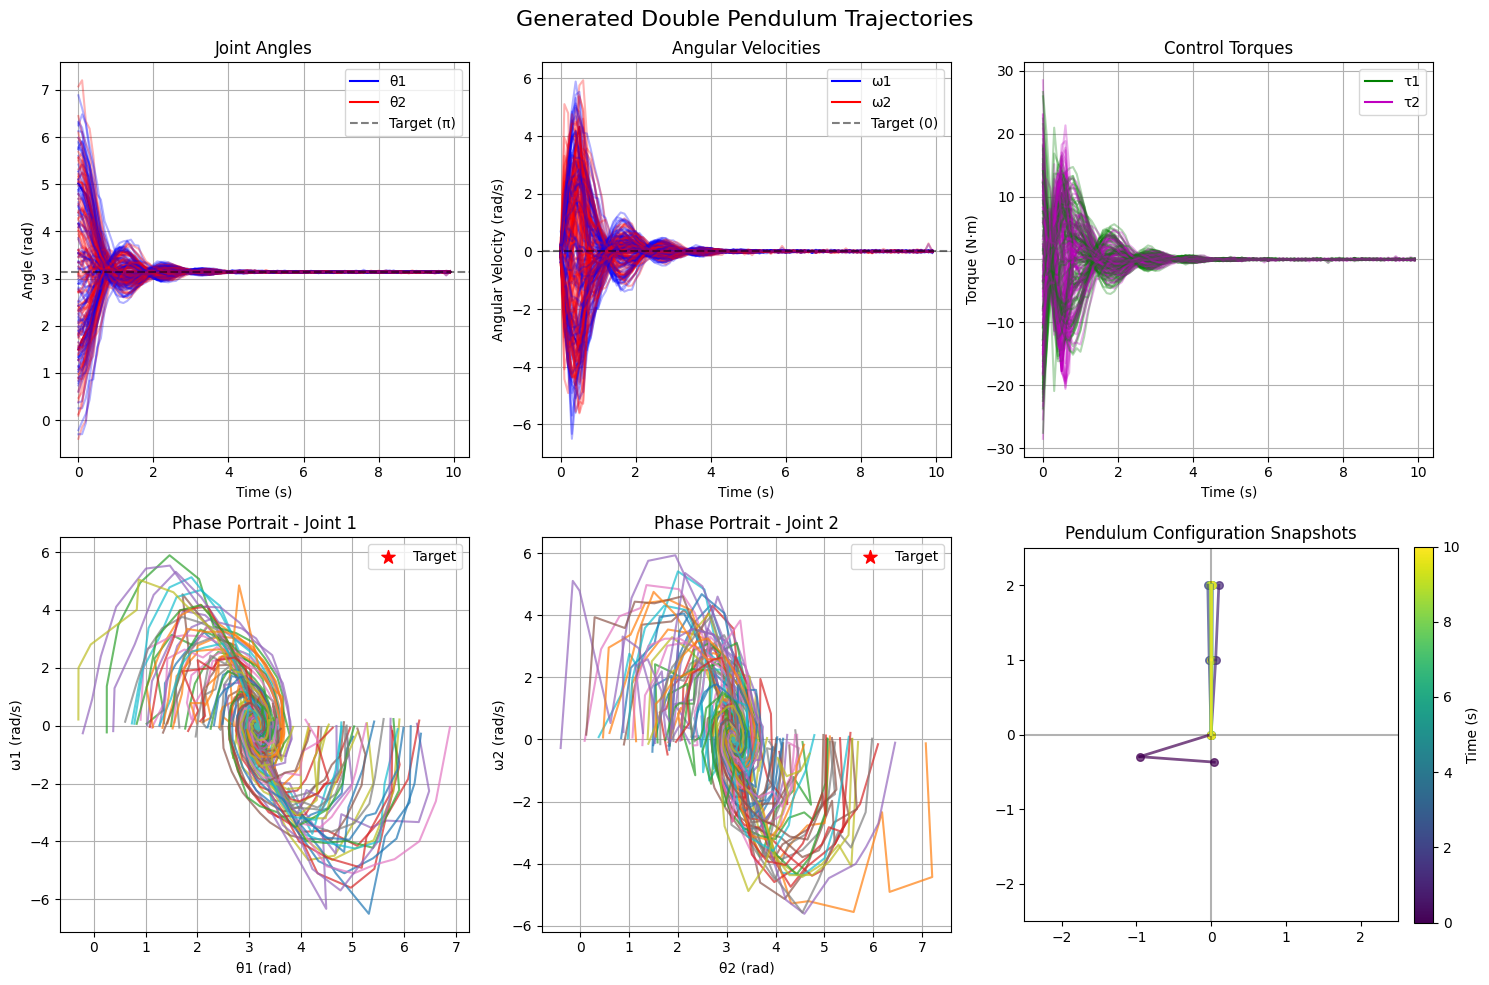

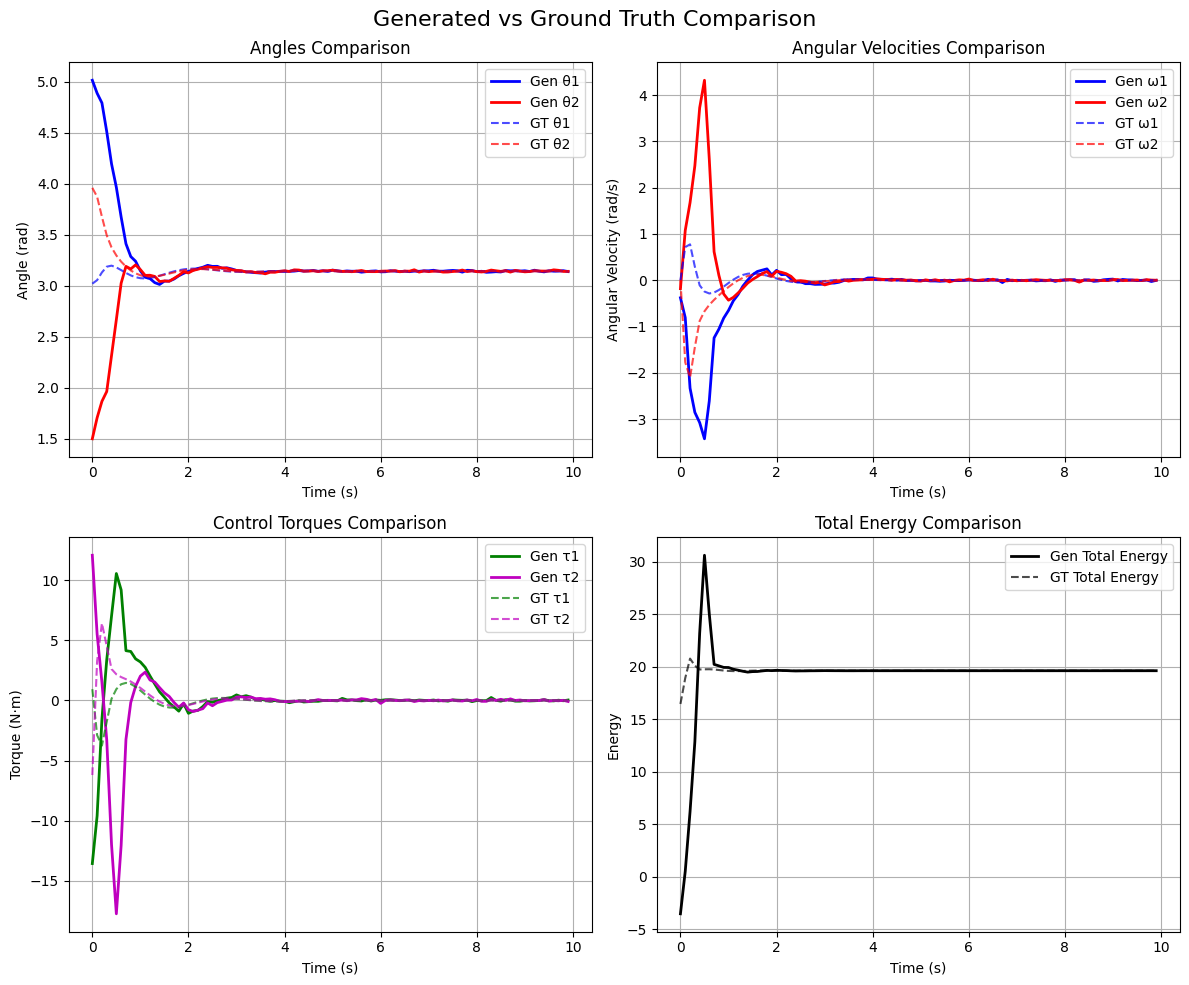

Statistical Analysis of Generated Trajectories:
Final θ1: 3.143 ± 0.005 rad
Final θ2: 3.142 ± 0.006 rad
Final ω1: -0.001 ± 0.014 rad/s
Final ω2: -0.001 ± 0.014 rad/s
Target: θ1=π, θ2=π, ω1=0, ω2=0

Average control effort: 3.643 ± 1.248 N·m

Average settling time: 1.08 ± 0.45 s

Inference completed successfully!


In [10]:
# Load checkpoint, ODE inference, denormalize & visualize

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Import necessary components
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

# %%
# 1. Load checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = 'mpc_pendulum_fm_best.pt'

# Load checkpoint

ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
print(f"Loaded checkpoint from epoch {ckpt['epoch']} with loss {ckpt['loss']:.6f}")

# Restore scalers
state_scaler = ckpt['state_scaler']
control_scaler = ckpt['control_scaler']

# %%
# 2. Recreate model architecture (must match training)
# You need to specify which model type was used during training
MODEL_TYPE = "transformer"  # Change this to match your training: "unet", "mlp", or "transformer"

if MODEL_TYPE == "unet":
    model = EfficientTemporalUNet(in_channels=6, base_channels=32)
elif MODEL_TYPE == "mlp":
    model = TemporalMLP(in_channels=6, hidden_dim=256, num_layers=6)
elif MODEL_TYPE == "transformer":
    model = SimpleFlowTransformer(in_channels=6, hidden_dim=128, num_heads=4, num_layers=4)

# Wrap in fmtorch compatible model
flow_model = MPCFlowModel(model).to(device)
flow_model.load_state_dict(ckpt['model_state_dict'])
flow_model.eval()

print(f"Model loaded successfully ({MODEL_TYPE})")

# %%
# 3. ODE-based inference for multiple trajectories
import torchdiffeq

# Number of samples to generate
num_samples = 100

# Store generated trajectories
generated_trajectories = []

# Define ODE function for torchdiffeq
def ode_func(t, x_flat):
    # Reshape to (batch, channels, time)
    batch_size = 1
    x = x_flat.view(batch_size, 6, 100)
    
    # Convert scalar t to tensor with correct shape
    t_tensor = torch.ones(batch_size, device=x.device) * t
    
    # Get velocity from flow model
    with torch.set_grad_enabled(False):
        v = flow_model(x, t_tensor)
    
    return v.view(-1)

with torch.no_grad():
    for i in range(num_samples):
        # Random noise initialization
        x0_noise = torch.randn((1, 6, 100), device=device)
        
        # Time span for ODE integration
        t_span = torch.linspace(0, 1, 2, device=device)
        
        # Solve ODE using torchdiffeq
        traj = torchdiffeq.odeint(
            ode_func,
            x0_noise.view(-1),
            t_span,
            method='dopri5',
            atol=1e-5,
            rtol=1e-5
        )
        
        # Get final state and reshape
        x_final = traj[-1].view(6, 100).cpu().numpy()  # (6, 100)
        
        # Split and denormalize
        states_norm = x_final[:4, :].T    # (100, 4)
        controls_norm = x_final[4:, :].T   # (100, 2)
        
        states = state_scaler.denormalize(states_norm)
        controls = control_scaler.denormalize(controls_norm)
        
        generated_trajectories.append({
            'states': states,
            'controls': controls,
            'states_norm': states_norm,
            'controls_norm': controls_norm
        })

print(f"Generated {num_samples} trajectories")

# %%
# 4. Visualize generated trajectories
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Generated Double Pendulum Trajectories', fontsize=16)

time_steps = np.arange(100) * 0.1

# Select one trajectory for detailed view
traj = generated_trajectories[0]
states = traj['states']
controls = traj['controls']

# Plot 1: Angles over time
ax = axes[0, 0]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 0], 'b-', alpha=alpha, label='θ1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 1], 'r-', alpha=alpha, label='θ2' if i == 0 else '')
ax.axhline(y=np.pi, color='k', linestyle='--', alpha=0.5, label='Target (π)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Joint Angles')
ax.legend()
ax.grid(True)

# Plot 2: Angular velocities over time
ax = axes[0, 1]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 2], 'b-', alpha=alpha, label='ω1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 3], 'r-', alpha=alpha, label='ω2' if i == 0 else '')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Target (0)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities')
ax.legend()
ax.grid(True)

# Plot 3: Control torques over time
ax = axes[0, 2]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['controls'][:, 0], 'g-', alpha=alpha, label='τ1' if i == 0 else '')
    ax.plot(time_steps, traj['controls'][:, 1], 'm-', alpha=alpha, label='τ2' if i == 0 else '')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques')
ax.legend()
ax.grid(True)

# Plot 4: Phase portrait (θ1 vs ω1)
ax = axes[1, 0]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 0], traj['states'][:, 2], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ1 (rad)')
ax.set_ylabel('ω1 (rad/s)')
ax.set_title('Phase Portrait - Joint 1')
ax.legend()
ax.grid(True)

# Plot 5: Phase portrait (θ2 vs ω2)
ax = axes[1, 1]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 1], traj['states'][:, 3], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ2 (rad)')
ax.set_ylabel('ω2 (rad/s)')
ax.set_title('Phase Portrait - Joint 2')
ax.legend()
ax.grid(True)

# Plot 6: Pendulum snapshots
ax = axes[1, 2]
ax.set_title('Pendulum Configuration Snapshots')
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# Draw pendulum at different time steps
snapshot_indices = np.linspace(0, 99, 10, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshot_indices)))

for idx, color in zip(snapshot_indices, colors):
    θ1, θ2 = states[idx, 0], states[idx, 1]
    x1, y1 = np.sin(θ1), -np.cos(θ1)
    x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
    
    ax.plot([0, x1], [0, y1], color=color, linewidth=2, alpha=0.7)
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2, alpha=0.7)
    ax.scatter([0, x1, x2], [0, y1, y2], color=color, s=30, alpha=0.7)

# Add colorbar for time
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=10))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time (s)')

plt.tight_layout()
plt.show()

# %%
# 5. Animate the pendulum motion
def animate_pendulum(states, interval=50):
    """Create animation of the double pendulum motion"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Double Pendulum Animation')
    
    # Initialize pendulum elements
    line1, = ax.plot([], [], 'b-', lw=3, label='Link 1')
    line2, = ax.plot([], [], 'r-', lw=3, label='Link 2')
    points, = ax.plot([], [], 'ko', markersize=8)
    
    # Trajectory traces
    trace1, = ax.plot([], [], 'b-', alpha=0.3, lw=1)
    trace2, = ax.plot([], [], 'r-', alpha=0.3, lw=1)
    
    trace1_x, trace1_y = [], []
    trace2_x, trace2_y = [], []
    
    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                       verticalalignment='top', fontsize=12)
    
    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        points.set_data([], [])
        trace1.set_data([], [])
        trace2.set_data([], [])
        time_text.set_text('')
        return line1, line2, points, trace1, trace2, time_text
    
    def animate(i):
        θ1, θ2 = states[i, 0], states[i, 1]
        
        # Calculate positions
        x1, y1 = np.sin(θ1), -np.cos(θ1)
        x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
        
        # Update pendulum
        line1.set_data([0, x1], [0, y1])
        line2.set_data([x1, x2], [y1, y2])
        points.set_data([0, x1, x2], [0, y1, y2])
        
        # Update traces
        trace1_x.append(x1)
        trace1_y.append(y1)
        trace2_x.append(x2)
        trace2_y.append(y2)
        
        # Keep only last 50 points for trace
        if len(trace1_x) > 50:
            trace1_x.pop(0)
            trace1_y.pop(0)
            trace2_x.pop(0)
            trace2_y.pop(0)
        
        trace1.set_data(trace1_x, trace1_y)
        trace2.set_data(trace2_x, trace2_y)
        
        # Update time
        time_text.set_text(f'Time: {i*0.1:.1f}s')
        
        return line1, line2, points, trace1, trace2, time_text
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=len(states), interval=interval,
                                 blit=True, repeat=True)
    
    plt.legend()
    plt.close()
    return anim

# Create animation
anim = animate_pendulum(generated_trajectories[0]['states'])
HTML(anim.to_jshtml())

# %%
# 6. Compare with ground truth (if available)
# Load a sample from the original MPC data for comparison
original_data = np.load('mpc_trajectories.npy')
gt_idx = np.random.randint(len(original_data))
gt_traj = original_data[gt_idx]
gt_states = gt_traj[:, :4]
gt_controls = gt_traj[:, 4:]

# Compare with generated trajectory
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Generated vs Ground Truth Comparison', fontsize=16)

# Angles comparison
ax = axes[0, 0]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 0], 'b-', label='Gen θ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 1], 'r-', label='Gen θ2', linewidth=2)
ax.plot(time_steps, gt_states[:, 0], 'b--', label='GT θ1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 1], 'r--', label='GT θ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Angles Comparison')
ax.legend()
ax.grid(True)

# Angular velocities comparison
ax = axes[0, 1]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 2], 'b-', label='Gen ω1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 3], 'r-', label='Gen ω2', linewidth=2)
ax.plot(time_steps, gt_states[:, 2], 'b--', label='GT ω1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 3], 'r--', label='GT ω2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities Comparison')
ax.legend()
ax.grid(True)

# Control torques comparison
ax = axes[1, 0]
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 0], 'g-', label='Gen τ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 1], 'm-', label='Gen τ2', linewidth=2)
ax.plot(time_steps, gt_controls[:, 0], 'g--', label='GT τ1', alpha=0.7)
ax.plot(time_steps, gt_controls[:, 1], 'm--', label='GT τ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques Comparison')
ax.legend()
ax.grid(True)

# Energy analysis
ax = axes[1, 1]
# Calculate total energy for generated trajectory
gen_states = generated_trajectories[0]['states']
gen_kinetic = 0.5 * (gen_states[:, 2]**2 + gen_states[:, 3]**2)
gen_potential = -9.81 * (np.cos(gen_states[:, 0]) + np.cos(gen_states[:, 1]))
gen_total_energy = gen_kinetic + gen_potential

# Calculate total energy for ground truth
gt_kinetic = 0.5 * (gt_states[:, 2]**2 + gt_states[:, 3]**2)
gt_potential = -9.81 * (np.cos(gt_states[:, 0]) + np.cos(gt_states[:, 1]))
gt_total_energy = gt_kinetic + gt_potential

ax.plot(time_steps, gen_total_energy, 'k-', label='Gen Total Energy', linewidth=2)
ax.plot(time_steps, gt_total_energy, 'k--', label='GT Total Energy', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy')
ax.set_title('Total Energy Comparison')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# %%
# 7. Statistical analysis of generated trajectories
print("Statistical Analysis of Generated Trajectories:")
print("=" * 50)

# Final state statistics
final_angles = np.array([traj['states'][-1, :2] for traj in generated_trajectories])
final_velocities = np.array([traj['states'][-1, 2:] for traj in generated_trajectories])

print(f"Final θ1: {final_angles[:, 0].mean():.3f} ± {final_angles[:, 0].std():.3f} rad")
print(f"Final θ2: {final_angles[:, 1].mean():.3f} ± {final_angles[:, 1].std():.3f} rad")
print(f"Final ω1: {final_velocities[:, 0].mean():.3f} ± {final_velocities[:, 0].std():.3f} rad/s")
print(f"Final ω2: {final_velocities[:, 1].mean():.3f} ± {final_velocities[:, 1].std():.3f} rad/s")
print(f"Target: θ1=π, θ2=π, ω1=0, ω2=0")

# Control effort statistics
control_effort = [np.sqrt((traj['controls']**2).sum(axis=1).mean()) for traj in generated_trajectories]
print(f"\nAverage control effort: {np.mean(control_effort):.3f} ± {np.std(control_effort):.3f} N·m")

# Settling time (when both angles are within 0.1 rad of π)
settling_times = []
for traj in generated_trajectories:
    angles = traj['states'][:, :2]
    settled = np.where((np.abs(angles[:, 0] - np.pi) < 0.1) & 
                      (np.abs(angles[:, 1] - np.pi) < 0.1))[0]
    if len(settled) > 0:
        settling_times.append(settled[0] * 0.1)
    else:
        settling_times.append(10.0)  # Max time

print(f"\nAverage settling time: {np.mean(settling_times):.2f} ± {np.std(settling_times):.2f} s")

print("\nInference completed successfully!")

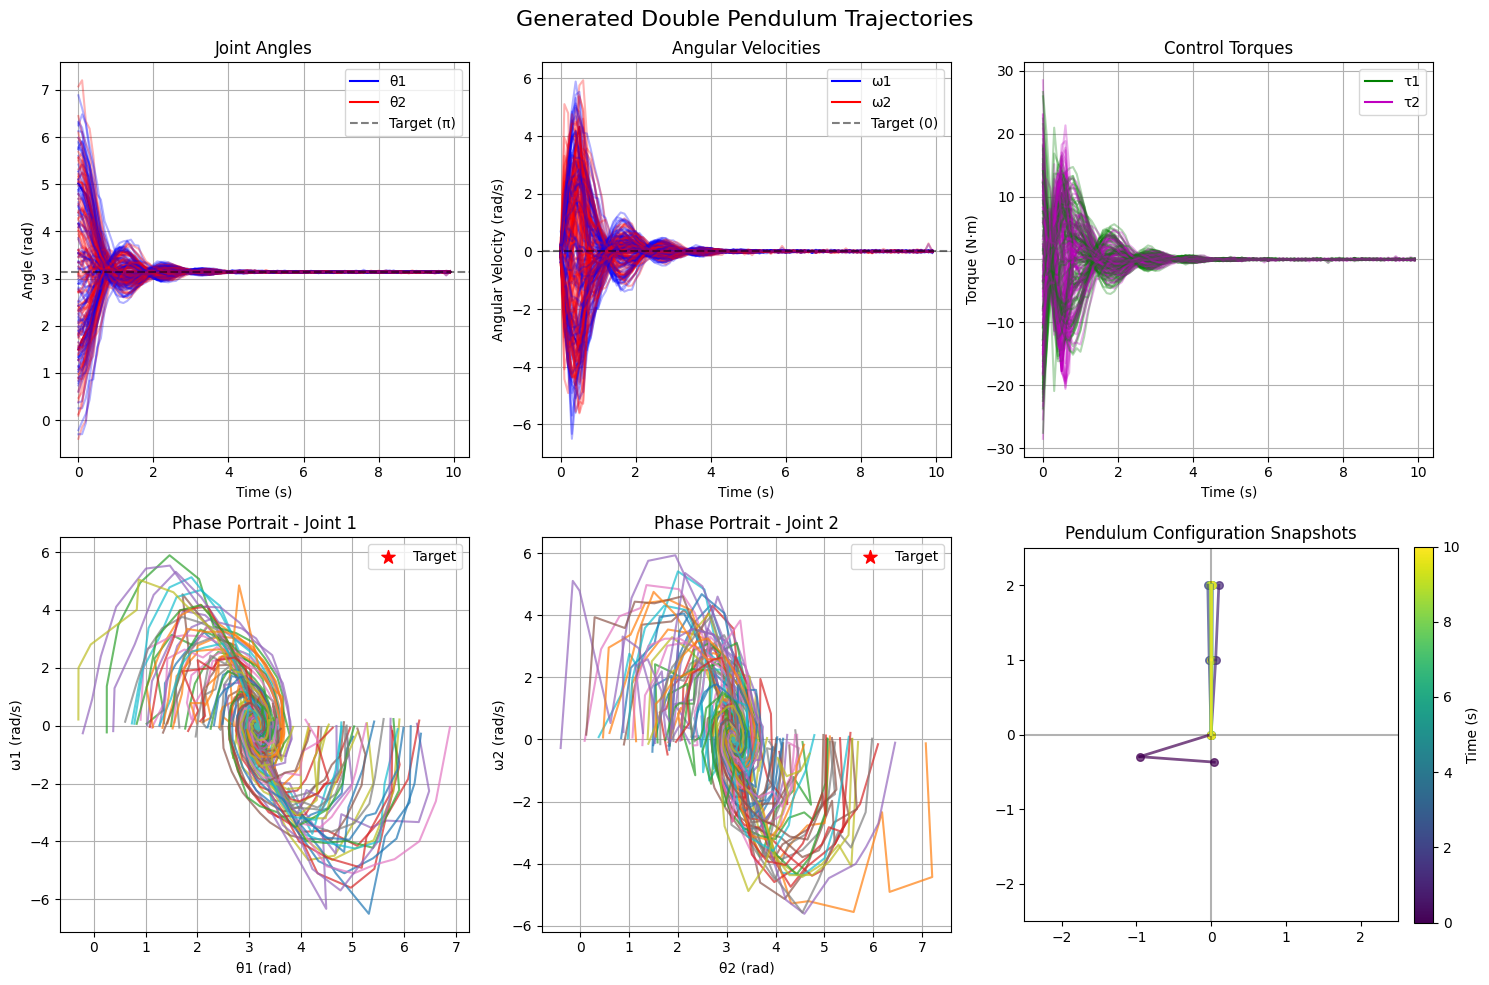

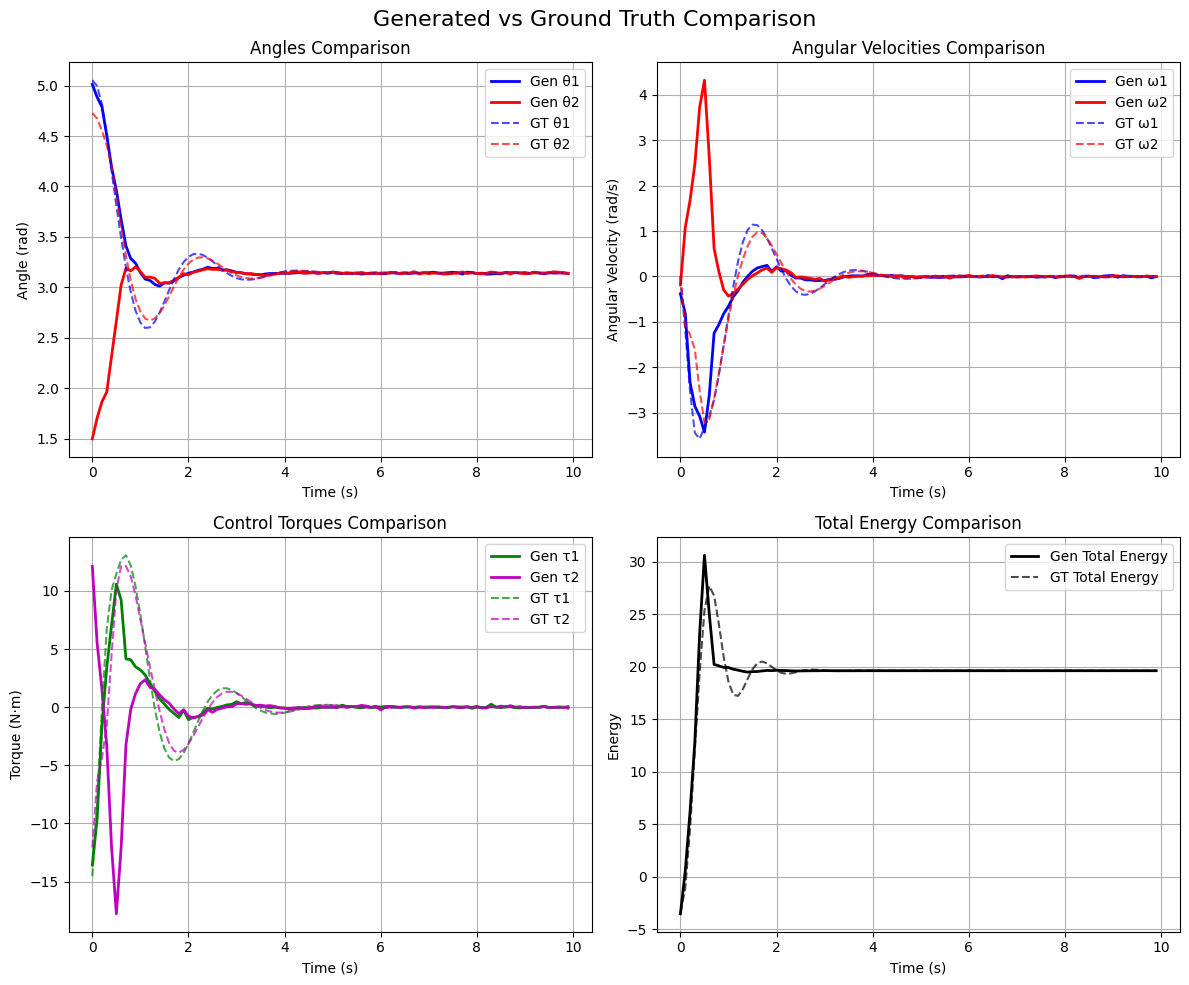


Control Effectiveness Evaluation:
Traj   Gen Final    Sim Final    State RMSE   Gen Inverted Sim Inverted
--------------------------------------------------------------------------------
0      0.0058       0.4729       0.2910       Yes          No          
1      0.0165       0.5420       0.2219       Yes          Yes         
2      0.0108       1.3322       0.4852       Yes          No          
3      0.0151       1.1884       0.4653       Yes          No          
4      0.0074       0.4251       0.2665       Yes          No          
5      0.0099       0.7252       0.5880       Yes          No          
6      0.0117       1.7779       0.5523       Yes          Yes         
7      0.0042       0.3094       0.2811       Yes          No          
8      0.0159       1.5519       0.5599       Yes          No          
9      0.0121       0.6427       0.6060       Yes          No          
10     0.0081       0.5445       0.4496       Yes          No          
11     0.0116       

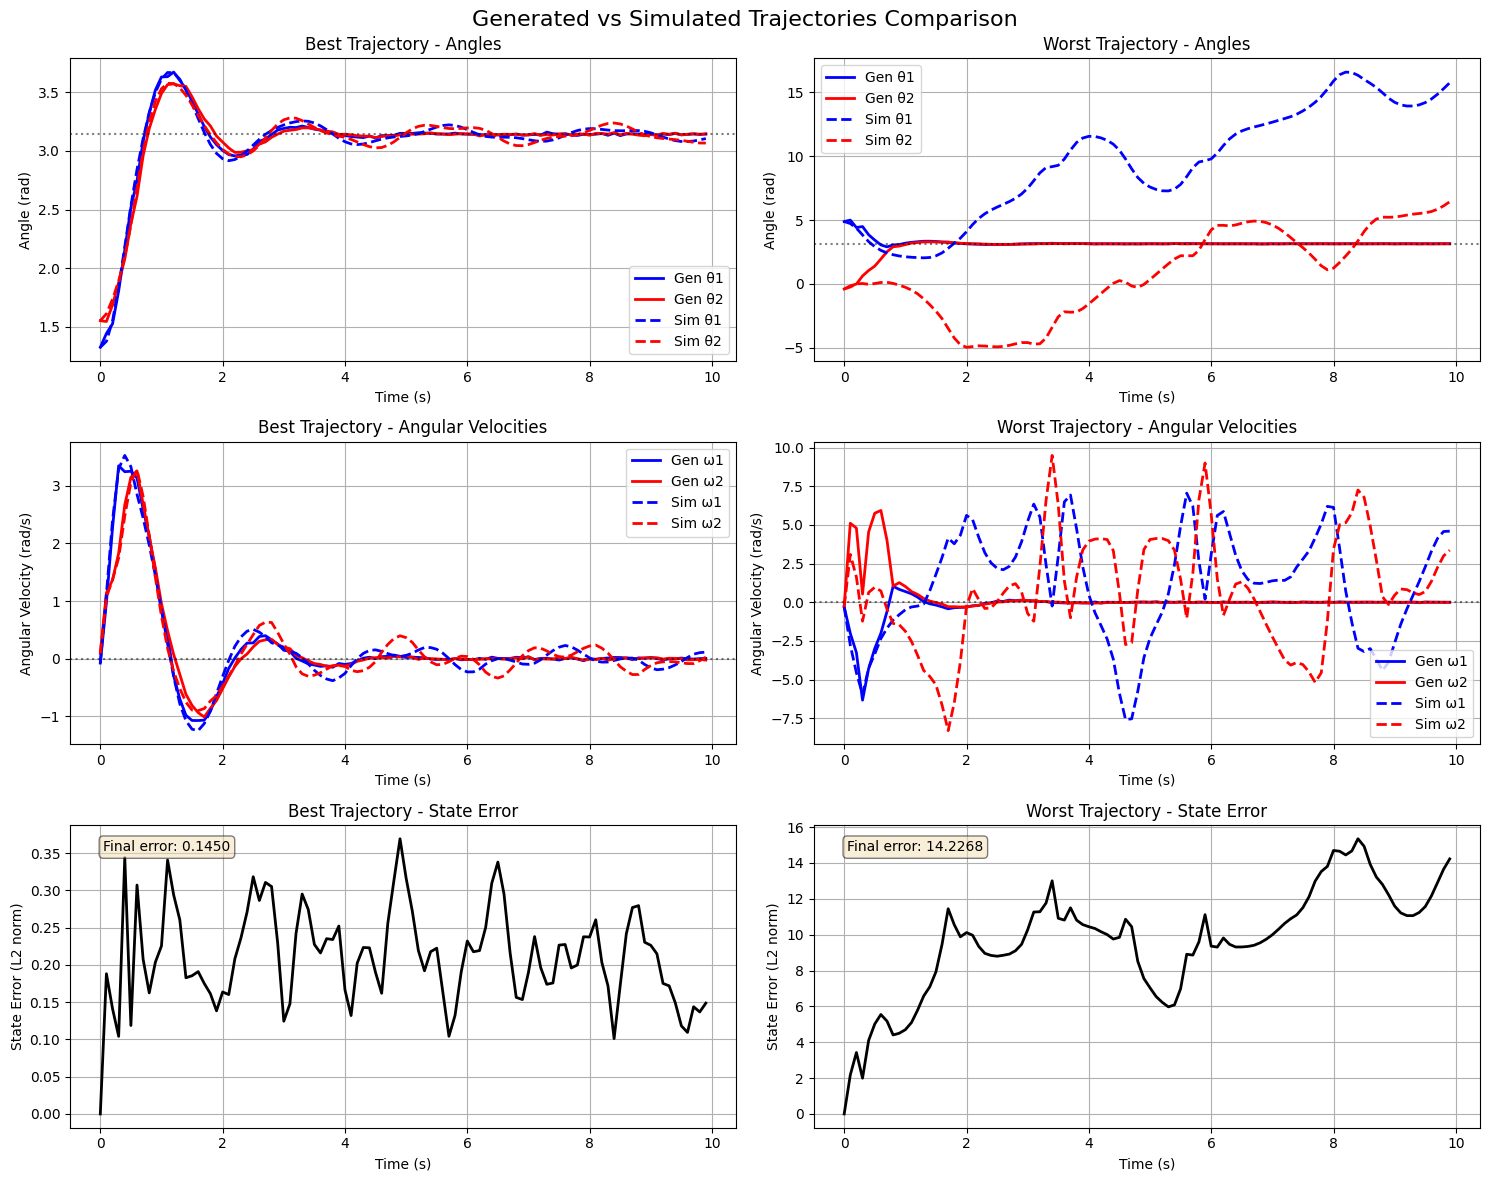


Evaluation completed successfully!


In [11]:
#Dynamic check
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Generated Double Pendulum Trajectories', fontsize=16)

time_steps = np.arange(100) * 0.1

# Select one trajectory for detailed view
traj = generated_trajectories[0]
states = traj['states']
controls = traj['controls']

# Plot 1: Angles over time
ax = axes[0, 0]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 0], 'b-', alpha=alpha, label='θ1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 1], 'r-', alpha=alpha, label='θ2' if i == 0 else '')
ax.axhline(y=np.pi, color='k', linestyle='--', alpha=0.5, label='Target (π)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Joint Angles')
ax.legend()
ax.grid(True)

# Plot 2: Angular velocities over time
ax = axes[0, 1]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['states'][:, 2], 'b-', alpha=alpha, label='ω1' if i == 0 else '')
    ax.plot(time_steps, traj['states'][:, 3], 'r-', alpha=alpha, label='ω2' if i == 0 else '')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Target (0)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities')
ax.legend()
ax.grid(True)

# Plot 3: Control torques over time
ax = axes[0, 2]
for i, traj in enumerate(generated_trajectories):
    alpha = 0.3 if i > 0 else 1.0
    ax.plot(time_steps, traj['controls'][:, 0], 'g-', alpha=alpha, label='τ1' if i == 0 else '')
    ax.plot(time_steps, traj['controls'][:, 1], 'm-', alpha=alpha, label='τ2' if i == 0 else '')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques')
ax.legend()
ax.grid(True)

# Plot 4: Phase portrait (θ1 vs ω1)
ax = axes[1, 0]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 0], traj['states'][:, 2], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ1 (rad)')
ax.set_ylabel('ω1 (rad/s)')
ax.set_title('Phase Portrait - Joint 1')
ax.legend()
ax.grid(True)

# Plot 5: Phase portrait (θ2 vs ω2)
ax = axes[1, 1]
for traj in generated_trajectories:
    ax.plot(traj['states'][:, 1], traj['states'][:, 3], '-', alpha=0.7)
ax.scatter([np.pi], [0], c='r', s=100, marker='*', label='Target')
ax.set_xlabel('θ2 (rad)')
ax.set_ylabel('ω2 (rad/s)')
ax.set_title('Phase Portrait - Joint 2')
ax.legend()
ax.grid(True)

# Plot 6: Pendulum snapshots
ax = axes[1, 2]
ax.set_title('Pendulum Configuration Snapshots')
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# Draw pendulum at different time steps
snapshot_indices = np.linspace(0, 99, 10, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshot_indices)))

for idx, color in zip(snapshot_indices, colors):
    θ1, θ2 = states[idx, 0], states[idx, 1]
    x1, y1 = np.sin(θ1), -np.cos(θ1)
    x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
    
    ax.plot([0, x1], [0, y1], color=color, linewidth=2, alpha=0.7)
    ax.plot([x1, x2], [y1, y2], color=color, linewidth=2, alpha=0.7)
    ax.scatter([0, x1, x2], [0, y1, y2], color=color, s=30, alpha=0.7)

# Add colorbar for time
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=10))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time (s)')

plt.tight_layout()
plt.show()

# %%
# 5. Animate the pendulum motion
def animate_pendulum(states, interval=50):
    """Create animation of the double pendulum motion"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Double Pendulum Animation')
    
    # Initialize pendulum elements
    line1, = ax.plot([], [], 'b-', lw=3, label='Link 1')
    line2, = ax.plot([], [], 'r-', lw=3, label='Link 2')
    points, = ax.plot([], [], 'ko', markersize=8)
    
    # Trajectory traces
    trace1, = ax.plot([], [], 'b-', alpha=0.3, lw=1)
    trace2, = ax.plot([], [], 'r-', alpha=0.3, lw=1)
    
    trace1_x, trace1_y = [], []
    trace2_x, trace2_y = [], []
    
    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                       verticalalignment='top', fontsize=12)
    
    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        points.set_data([], [])
        trace1.set_data([], [])
        trace2.set_data([], [])
        time_text.set_text('')
        return line1, line2, points, trace1, trace2, time_text
    
    def animate(i):
        θ1, θ2 = states[i, 0], states[i, 1]
        
        # Calculate positions
        x1, y1 = np.sin(θ1), -np.cos(θ1)
        x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
        
        # Update pendulum
        line1.set_data([0, x1], [0, y1])
        line2.set_data([x1, x2], [y1, y2])
        points.set_data([0, x1, x2], [0, y1, y2])
        
        # Update traces
        trace1_x.append(x1)
        trace1_y.append(y1)
        trace2_x.append(x2)
        trace2_y.append(y2)
        
        # Keep only last 50 points for trace
        if len(trace1_x) > 50:
            trace1_x.pop(0)
            trace1_y.pop(0)
            trace2_x.pop(0)
            trace2_y.pop(0)
        
        trace1.set_data(trace1_x, trace1_y)
        trace2.set_data(trace2_x, trace2_y)
        
        # Update time
        time_text.set_text(f'Time: {i*0.1:.1f}s')
        
        return line1, line2, points, trace1, trace2, time_text
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=len(states), interval=interval,
                                 blit=True, repeat=True)
    
    plt.legend()
    plt.close()
    return anim

# Create animation
anim = animate_pendulum(generated_trajectories[0]['states'])
HTML(anim.to_jshtml())

# %%
# 6. Compare with ground truth (if available)
# Load a sample from the original MPC data for comparison
original_data = np.load('mpc_trajectories.npy')
gt_idx = np.random.randint(len(original_data))
gt_traj = original_data[gt_idx]
gt_states = gt_traj[:, :4]
gt_controls = gt_traj[:, 4:]

# Compare with generated trajectory
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Generated vs Ground Truth Comparison', fontsize=16)

# Angles comparison
ax = axes[0, 0]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 0], 'b-', label='Gen θ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 1], 'r-', label='Gen θ2', linewidth=2)
ax.plot(time_steps, gt_states[:, 0], 'b--', label='GT θ1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 1], 'r--', label='GT θ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (rad)')
ax.set_title('Angles Comparison')
ax.legend()
ax.grid(True)

# Angular velocities comparison
ax = axes[0, 1]
ax.plot(time_steps, generated_trajectories[0]['states'][:, 2], 'b-', label='Gen ω1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['states'][:, 3], 'r-', label='Gen ω2', linewidth=2)
ax.plot(time_steps, gt_states[:, 2], 'b--', label='GT ω1', alpha=0.7)
ax.plot(time_steps, gt_states[:, 3], 'r--', label='GT ω2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocities Comparison')
ax.legend()
ax.grid(True)

# Control torques comparison
ax = axes[1, 0]
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 0], 'g-', label='Gen τ1', linewidth=2)
ax.plot(time_steps, generated_trajectories[0]['controls'][:, 1], 'm-', label='Gen τ2', linewidth=2)
ax.plot(time_steps, gt_controls[:, 0], 'g--', label='GT τ1', alpha=0.7)
ax.plot(time_steps, gt_controls[:, 1], 'm--', label='GT τ2', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque (N·m)')
ax.set_title('Control Torques Comparison')
ax.legend()
ax.grid(True)

# Energy analysis
ax = axes[1, 1]
# Calculate total energy for generated trajectory
gen_states = generated_trajectories[0]['states']
gen_kinetic = 0.5 * (gen_states[:, 2]**2 + gen_states[:, 3]**2)
gen_potential = -9.81 * (np.cos(gen_states[:, 0]) + np.cos(gen_states[:, 1]))
gen_total_energy = gen_kinetic + gen_potential

# Calculate total energy for ground truth
gt_kinetic = 0.5 * (gt_states[:, 2]**2 + gt_states[:, 3]**2)
gt_potential = -9.81 * (np.cos(gt_states[:, 0]) + np.cos(gt_states[:, 1]))
gt_total_energy = gt_kinetic + gt_potential

ax.plot(time_steps, gen_total_energy, 'k-', label='Gen Total Energy', linewidth=2)
ax.plot(time_steps, gt_total_energy, 'k--', label='GT Total Energy', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy')
ax.set_title('Total Energy Comparison')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# %%
# 8. Simulate dynamics with generated controls and evaluate performance

# First, let's define the double pendulum dynamics for simulation
class DoublePendulumDynamics:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        θ1, θ2, ω1, ω2 = state
        Δ = θ2 - θ1
        M11 = (self.m1 + self.m2) * self.l1**2
        M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
        M21 = M12
        M22 = self.m2 * self.l2**2
        C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
        G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
        G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
        M = np.array([[M11, M12],[M21, M22]])
        dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)

# Create dynamics model
dyn = DoublePendulumDynamics()
dt = 0.1

# Simulate each generated trajectory
simulation_results = []

for i, traj in enumerate(generated_trajectories):
    # Get initial state from generated trajectory
    x0 = traj['states'][0, :]  # [θ1, θ2, ω1, ω2]
    controls = traj['controls']  # (100, 2)
    
    # Simulate with the generated controls
    simulated_states = [x0.copy()]
    for t in range(99):  # 99 steps to get 100 states
        u = controls[t]
        x_next = dyn.rk4_step(simulated_states[-1], u, dt)
        simulated_states.append(x_next)
    
    simulated_states = np.array(simulated_states)
    
    # Store results
    simulation_results.append({
        'generated_states': traj['states'],
        'simulated_states': simulated_states,
        'controls': controls,
        'initial_state': x0
    })

# %%
# 9. Evaluate control effectiveness

# Target state
target_state = np.array([np.pi, np.pi, 0.0, 0.0])

# Evaluation metrics
evaluation_metrics = []

for i, result in enumerate(simulation_results):
    gen_states = result['generated_states']
    sim_states = result['simulated_states']
    
    # Final state errors
    gen_final = gen_states[-1]
    sim_final = sim_states[-1]
    
    gen_error = np.linalg.norm(gen_final - target_state)
    sim_error = np.linalg.norm(sim_final - target_state)
    
    # Angle errors at final time
    gen_angle_error = np.sqrt((gen_final[0] - np.pi)**2 + (gen_final[1] - np.pi)**2)
    sim_angle_error = np.sqrt((sim_final[0] - np.pi)**2 + (sim_final[1] - np.pi)**2)
    
    # Velocity errors at final time
    gen_vel_error = np.sqrt(gen_final[2]**2 + gen_final[3]**2)
    sim_vel_error = np.sqrt(sim_final[2]**2 + sim_final[3]**2)
    
    # State trajectory error (RMSE)
    state_rmse = np.sqrt(np.mean((gen_states - sim_states)**2))
    
    # Check if successfully inverted (both angles within 0.1 rad of π)
    gen_inverted = (abs(gen_final[0] - np.pi) < 0.1) and (abs(gen_final[1] - np.pi) < 0.1)
    sim_inverted = (abs(sim_final[0] - np.pi) < 0.1) and (abs(sim_final[1] - np.pi) < 0.1)
    
    # Control effort
    control_effort = np.sqrt(np.mean(result['controls']**2))
    
    metrics = {
        'traj_idx': i,
        'gen_final_error': gen_error,
        'sim_final_error': sim_error,
        'gen_angle_error': gen_angle_error,
        'sim_angle_error': sim_angle_error,
        'gen_vel_error': gen_vel_error,
        'sim_vel_error': sim_vel_error,
        'state_rmse': state_rmse,
        'gen_inverted': gen_inverted,
        'sim_inverted': sim_inverted,
        'control_effort': control_effort
    }
    evaluation_metrics.append(metrics)

# Print evaluation results
print("\nControl Effectiveness Evaluation:")
print("=" * 80)
print(f"{'Traj':<6} {'Gen Final':<12} {'Sim Final':<12} {'State RMSE':<12} {'Gen Inverted':<12} {'Sim Inverted':<12}")
print("-" * 80)

for metrics in evaluation_metrics:
    print(f"{metrics['traj_idx']:<6} "
          f"{metrics['gen_final_error']:<12.4f} "
          f"{metrics['sim_final_error']:<12.4f} "
          f"{metrics['state_rmse']:<12.4f} "
          f"{'Yes' if metrics['gen_inverted'] else 'No':<12} "
          f"{'Yes' if metrics['sim_inverted'] else 'No':<12}")

# Summary statistics
sim_success_rate = sum(m['sim_inverted'] for m in evaluation_metrics) / len(evaluation_metrics)
avg_sim_error = np.mean([m['sim_final_error'] for m in evaluation_metrics])
avg_state_rmse = np.mean([m['state_rmse'] for m in evaluation_metrics])

print("\nSummary:")
print(f"Simulation success rate: {sim_success_rate:.1%}")
print(f"Average final state error (simulation): {avg_sim_error:.4f}")
print(f"Average state trajectory RMSE: {avg_state_rmse:.4f}")

# %%
# 10. Visualize comparison between generated and simulated trajectories

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Generated vs Simulated Trajectories Comparison', fontsize=16)

# Select best and worst trajectories based on simulation error
best_idx = min(range(len(evaluation_metrics)), 
               key=lambda i: evaluation_metrics[i]['sim_final_error'])
worst_idx = max(range(len(evaluation_metrics)), 
                key=lambda i: evaluation_metrics[i]['sim_final_error'])

time_steps = np.arange(100) * dt

for idx, label in [(best_idx, 'Best'), (worst_idx, 'Worst')]:
    result = simulation_results[idx]
    gen_states = result['generated_states']
    sim_states = result['simulated_states']
    controls = result['controls']
    
    col = 0 if label == 'Best' else 1
    
    # Angles
    ax = axes[0, col]
    ax.plot(time_steps, gen_states[:, 0], 'b-', label='Gen θ1', linewidth=2)
    ax.plot(time_steps, gen_states[:, 1], 'r-', label='Gen θ2', linewidth=2)
    ax.plot(time_steps, sim_states[:, 0], 'b--', label='Sim θ1', linewidth=2)
    ax.plot(time_steps, sim_states[:, 1], 'r--', label='Sim θ2', linewidth=2)
    ax.axhline(y=np.pi, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angle (rad)')
    ax.set_title(f'{label} Trajectory - Angles')
    ax.legend()
    ax.grid(True)
    
    # Angular velocities
    ax = axes[1, col]
    ax.plot(time_steps, gen_states[:, 2], 'b-', label='Gen ω1', linewidth=2)
    ax.plot(time_steps, gen_states[:, 3], 'r-', label='Gen ω2', linewidth=2)
    ax.plot(time_steps, sim_states[:, 2], 'b--', label='Sim ω1', linewidth=2)
    ax.plot(time_steps, sim_states[:, 3], 'r--', label='Sim ω2', linewidth=2)
    ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angular Velocity (rad/s)')
    ax.set_title(f'{label} Trajectory - Angular Velocities')
    ax.legend()
    ax.grid(True)
    
    # State error
    ax = axes[2, col]
    state_error = np.linalg.norm(gen_states - sim_states, axis=1)
    ax.plot(time_steps, state_error, 'k-', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('State Error (L2 norm)')
    ax.set_title(f'{label} Trajectory - State Error')
    ax.grid(True)
    
    # Add text with final errors
    final_error = evaluation_metrics[idx]['sim_final_error']
    ax.text(0.05, 0.95, f'Final error: {final_error:.4f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# %%
# 11. Pendulum animation comparison

def animate_comparison(gen_states, sim_states, interval=50):
    """Create side-by-side animation comparing generated and simulated trajectories"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    for ax, title in [(ax1, 'Generated Trajectory'), (ax2, 'Simulated Trajectory')]:
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(title)
    
    # Initialize pendulum elements for both
    elements = []
    for ax in [ax1, ax2]:
        line1, = ax.plot([], [], 'b-', lw=3, label='Link 1')
        line2, = ax.plot([], [], 'r-', lw=3, label='Link 2')
        points, = ax.plot([], [], 'ko', markersize=8)
        trace1, = ax.plot([], [], 'b-', alpha=0.3, lw=1)
        trace2, = ax.plot([], [], 'r-', alpha=0.3, lw=1)
        time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                           verticalalignment='top', fontsize=12)
        elements.append((line1, line2, points, trace1, trace2, time_text, [], [], [], []))
    
    def init():
        for line1, line2, points, trace1, trace2, time_text, *_ in elements:
            line1.set_data([], [])
            line2.set_data([], [])
            points.set_data([], [])
            trace1.set_data([], [])
            trace2.set_data([], [])
            time_text.set_text('')
        return [item for elem in elements for item in elem[:6]]
    
    def animate(i):
        returns = []
        for states, (line1, line2, points, trace1, trace2, time_text, 
                     trace1_x, trace1_y, trace2_x, trace2_y) in zip([gen_states, sim_states], elements):
            θ1, θ2 = states[i, 0], states[i, 1]
            
            # Calculate positions
            x1, y1 = np.sin(θ1), -np.cos(θ1)
            x2, y2 = x1 + np.sin(θ2), y1 - np.cos(θ2)
            
            # Update pendulum
            line1.set_data([0, x1], [0, y1])
            line2.set_data([x1, x2], [y1, y2])
            points.set_data([0, x1, x2], [0, y1, y2])
            
            # Update traces
            trace1_x.append(x1)
            trace1_y.append(y1)
            trace2_x.append(x2)
            trace2_y.append(y2)
            
            # Keep only last 30 points
            if len(trace1_x) > 30:
                trace1_x.pop(0)
                trace1_y.pop(0)
                trace2_x.pop(0)
                trace2_y.pop(0)
            
            trace1.set_data(trace1_x, trace1_y)
            trace2.set_data(trace2_x, trace2_y)
            
            # Update time
            time_text.set_text(f'Time: {i*0.1:.1f}s')
            
            returns.extend([line1, line2, points, trace1, trace2, time_text])
        
        return returns
    
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                 frames=len(gen_states), interval=interval,
                                 blit=True, repeat=True)
    
    plt.tight_layout()
    plt.close()
    return anim

# Create comparison animation for the best trajectory
best_result = simulation_results[best_idx]
anim_comparison = animate_comparison(best_result['generated_states'], 
                                   best_result['simulated_states'])
HTML(anim_comparison.to_jshtml())

print("\nEvaluation completed successfully!")